# **Retail Sales Prediction and Business Analytics**

##Business Problem

Businesses generate thousands of sales transactions every day. Understanding sales trends, customer behavior, and product performance helps organizations make better decisions regarding inventory, marketing, and revenue growth.

This project performs end-to-end sales analysis using Python and Power BI and builds machine learning models to predict future sales.

**Import Libraries**

In [1]:
#import necessary library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**Load Dataset**

In [2]:
# import dataset

df = pd.read_csv("/content/SuperStoreOrders.csv.zip")

# **Data Understanding**

In this step, I explored the dataset to understand its structure, columns, data types, and basic statistics before cleaning the data.

In [3]:
# display first five rows
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [4]:
# display last 5 rows
df.tail()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
51285,CA-2014-115427,31-12-2014,4/1/2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31-12-2014,5/1/2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31-12-2014,2/1/2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31-12-2014,6/1/2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014
51289,CA-2014-156720,31-12-2014,4/1/2015,Standard Class,Jill Matthias,Consumer,Colorado,United States,US,West,...,Office Supplies,Fasteners,Bagged Rubber Bands,3,3,0.2,-0.6048,0.17,Medium,2014


In [5]:
# display shape of the dataset
df.shape

(51290, 21)

In [6]:
# display columns names
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')

In [7]:
# display datatype of the dataset
df.dtypes

,0
order_id,object
order_date,object
ship_date,object
ship_mode,object
customer_name,object
segment,object
state,object
country,object
market,object
region,object


In [8]:
# display information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [9]:
# display statistical summary
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


# **Data Cleaning**

In this step, I cleaned the dataset by handling missing values, removing duplicates, and fixing data types to make the data ready for analysis.

In [10]:
# display duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
# display null values
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [12]:
# change datatype of order date and ship date
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed',
    dayfirst=True
    )

df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    format='mixed',
    dayfirst=True
    )


In [13]:
df.head(10)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011
5,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",55,2,0.1,15.342,1.80,Medium,2011
6,CA-2011-1510,2011-01-02,2011-01-06,Standard Class,Magdelene Morse,Consumer,Ontario,Canada,Canada,Canada,...,Technology,Machines,"Okidata Inkjet, Wireless",314,1,0.0,3.120,24.10,Medium,2011
7,IN-2011-79397,2011-01-03,2011-01-03,Same Day,Kean Nguyen,Corporate,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Appliances,"Hoover Microwave, White",276,1,0.1,110.412,125.32,Critical,2011
8,ID-2011-80230,2011-01-03,2011-01-09,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,...,Technology,Copiers,"Hewlett Wireless Fax, Laser",912,4,0.4,-319.464,107.10,Low,2011
9,IZ-2011-4680,2011-01-03,2011-01-07,Standard Class,Lindsay Williams,Corporate,Ninawa,Iraq,EMEA,EMEA,...,Furniture,Chairs,"Novimex Swivel Stool, Set of Two",667,4,0.0,253.320,81.26,High,2011


# **Feature Engineering**

In this step, I created new features from the existing data to improve the machine learning model and EDA.

In [14]:
# Order Month
df['Order Month'] = df['order_date'].dt.month

# Month name
df['Month Name'] = df['order_date'].dt.month_name()

# Order days
df['Order Day'] = df['order_date'].dt.day

# Day name
df['Day Name'] = df['order_date'].dt.day_name()

# Quarter
df['Quarter'] = df['order_date'].dt.quarter



In [15]:
# Shipping days

df['Shipping Days'] = (df['ship_date'] - df['order_date']).dt.days

# Weekend Features

df['Weekend'] = df['Day Name'].isin(['Satuday','Sunday'])


In [16]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,shipping_cost,order_priority,year,Order Month,Month Name,Order Day,Day Name,Quarter,Shipping Days,Weekend
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,35.46,Medium,2011,1,January,1,Saturday,1,5,False
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,9.72,Medium,2011,1,January,1,Saturday,1,7,False
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,8.17,High,2011,1,January,1,Saturday,1,4,False
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,4.82,High,2011,1,January,1,Saturday,1,4,False
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,4.70,Medium,2011,1,January,1,Saturday,1,7,False


In [17]:
# Remove commas and convert the sales column to numeric format.
df['sales'] = df['sales'].str.replace(',', '', regex=False)

df['sales'] = pd.to_numeric(df['sales'])

# **Exploratory Data Analysis(EDA)**

In this step, I explored the data using charts to understand sales trends, customer behavior, and product performance.

In [18]:
# Create KPI's

# Total sales
print(f'Total Sales:{df['sales'].sum()}')

# Total orders
print(f'Total Orders: {df['order_id'].nunique()}')

# Total customers
print(f'Total Customers: {df['customer_name'].nunique()}')

# Average sales
print(f'Average Sales: {df['sales'].mean()}')

# Average Shipping days
print(f'Average Shipping days: {df['Shipping Days'].mean()}')


Total Sales:12642905
Total Orders: 25035
Total Customers: 795
Average Sales: 246.49844024176252
Average Shipping days: 3.96937024761162


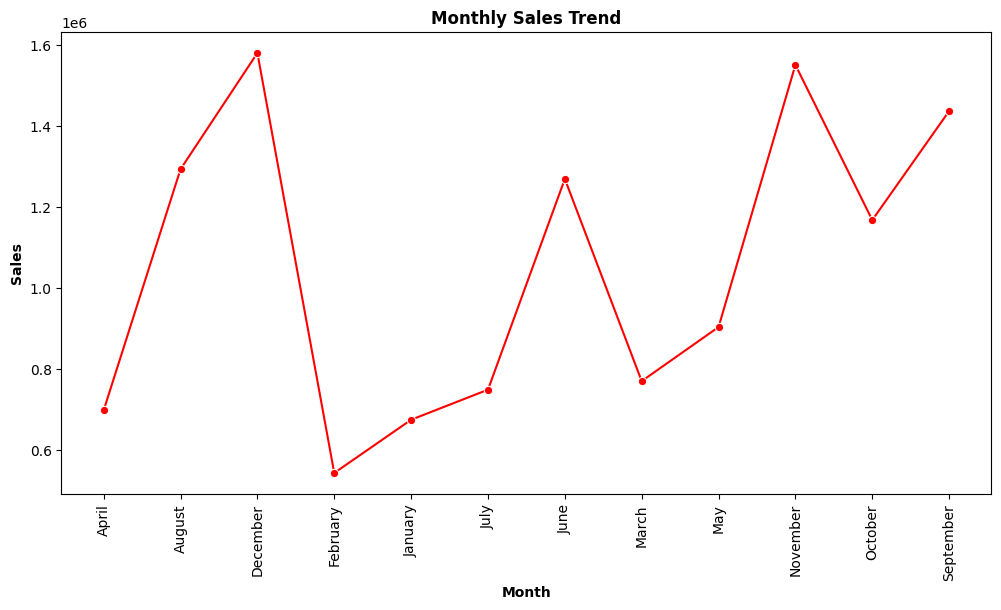

In [19]:
# monthly sales trend

monthly_sales = (
    df.groupby('Month Name')['sales'].sum()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    x = monthly_sales.index,
    y = monthly_sales.values,
    marker = 'o',
    color = 'red'
)

plt.title('Monthly Sales Trend', fontweight = 'bold')
plt.xlabel('Month',fontweight = 'bold')
plt.ylabel('Sales',fontweight = 'bold')
plt.xticks(rotation=90)
plt.show()

# Insight:
Sales are highest during November and December.

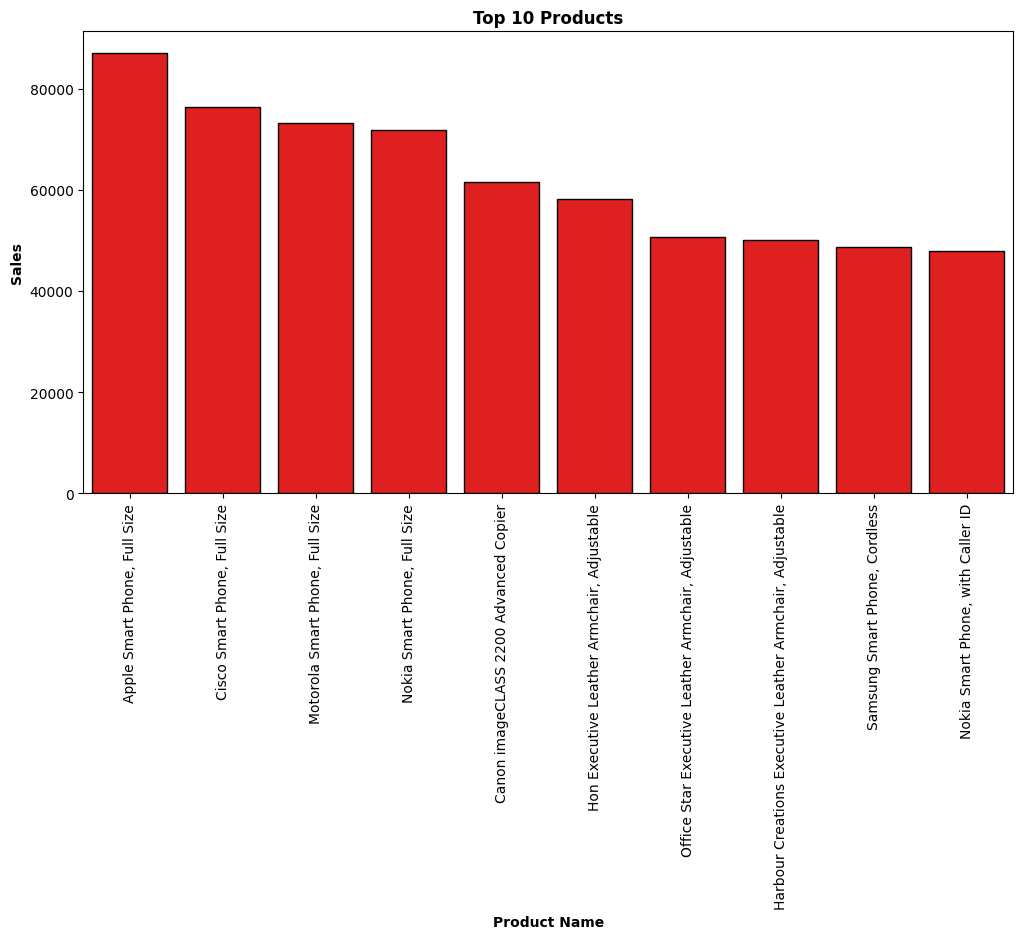

In [20]:
# Top 10 products

top_products = (df.groupby('product_name')['sales'].sum()
    .sort_values(ascending = False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x = top_products.index,
    y = top_products.values,
    color = 'red',
    edgecolor = 'black'
)

plt.title('Top 10 Products',fontweight = 'bold')
plt.xlabel('Product Name',fontweight = 'bold')
plt.ylabel('Sales',fontweight = 'bold')
plt.xticks(rotation = 90)
plt.show()

# Insight:
Apple smart phone, full size is the highest-selling product.

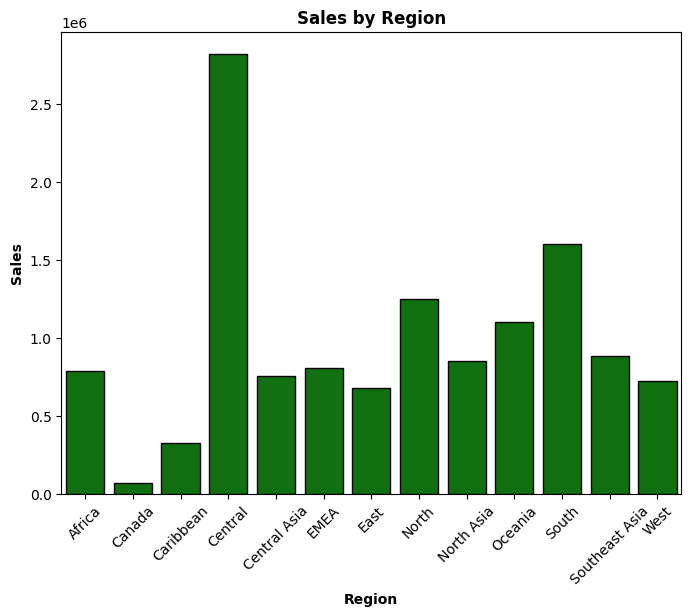

In [21]:
# Sales by region

region_sales = df.groupby('region')['sales'].sum()

plt.figure(figsize=(8,6))

sns.barplot(
    x = region_sales.index,
    y = region_sales.values,
    color = 'green',
    edgecolor = 'black'

)

plt.title('Sales by Region',fontweight = 'bold')
plt.xlabel('Region',fontweight = 'bold')
plt.ylabel('Sales',fontweight = 'bold')
plt.xticks(rotation=45)
plt.show()

# Insight:
The Cental region contributes the highest sales.

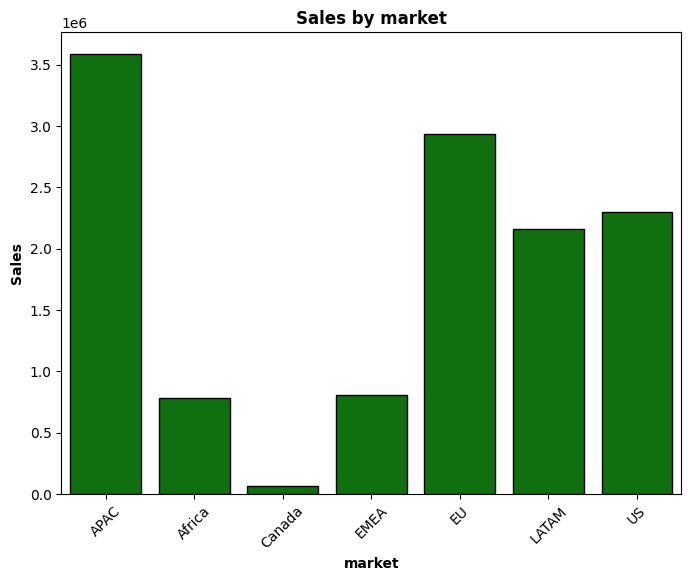

In [22]:
# Sales by market

region_sales = df.groupby('market')['sales'].sum()

plt.figure(figsize=(8,6))

sns.barplot(
    x = region_sales.index,
    y = region_sales.values,
    color = 'green',
    edgecolor = 'black'

)

plt.title('Sales by market',fontweight = 'bold')
plt.xlabel('market',fontweight = 'bold')
plt.ylabel('Sales',fontweight = 'bold')
plt.xticks(rotation=45)
plt.show()

# Insight:
 APAC market records the highest sales.

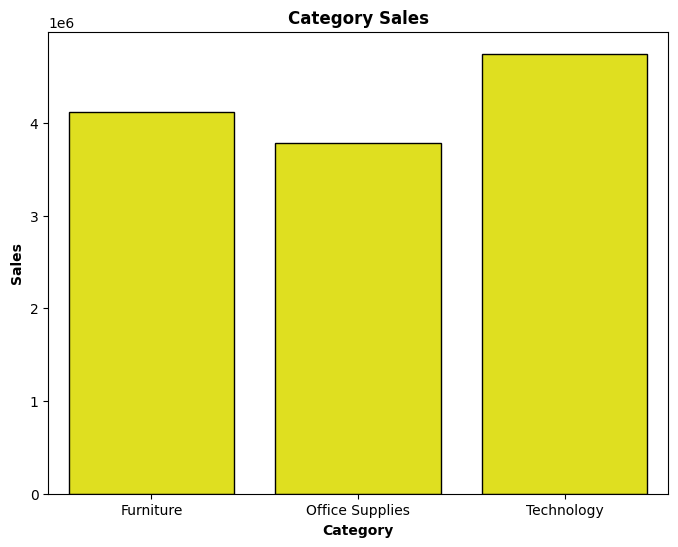

In [23]:
# category sales
category_sales = df.groupby('category')['sales'].sum()

plt.figure(figsize=(8,6))

sns.barplot(
    x=category_sales.index,
    y= category_sales.values,
    color = 'yellow',
    edgecolor = 'black'
)

plt.title('Category Sales',fontweight = 'bold')
plt.xlabel('Category',fontweight = 'bold')
plt.ylabel('Sales',fontweight = 'bold')
plt.show()

# Insight:
Technology is the best-performing category.

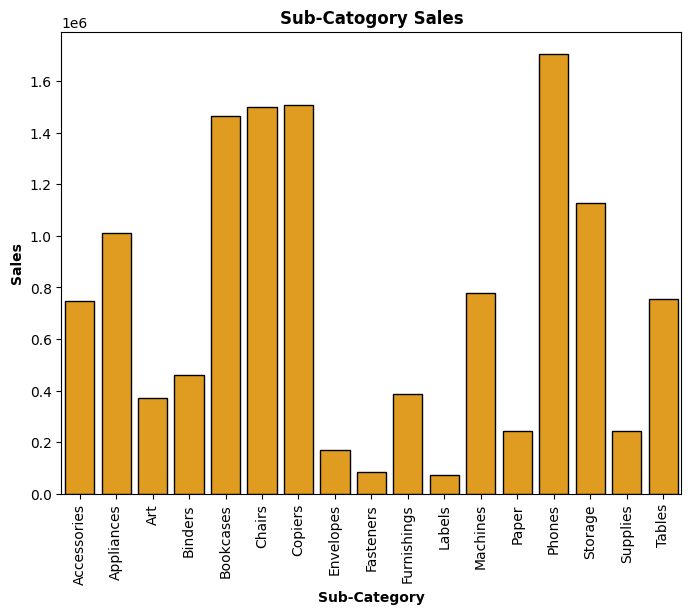

In [24]:
# sub-category sales
subcategory_sales = df.groupby('sub_category')['sales'].sum()

plt.figure(figsize=(8,6))

sns.barplot(
    x = subcategory_sales.index,
   y = subcategory_sales.values,
    color = 'orange',
    edgecolor = 'black'
)

plt.title('Sub-Catogory Sales',fontweight = 'bold')
plt.xlabel('Sub-Category',fontweight = 'bold')
plt.ylabel('Sales',fontweight = 'bold')
plt.xticks(rotation=90)
plt.show()

# Insight:
 Phones is the best-performing sub-category.

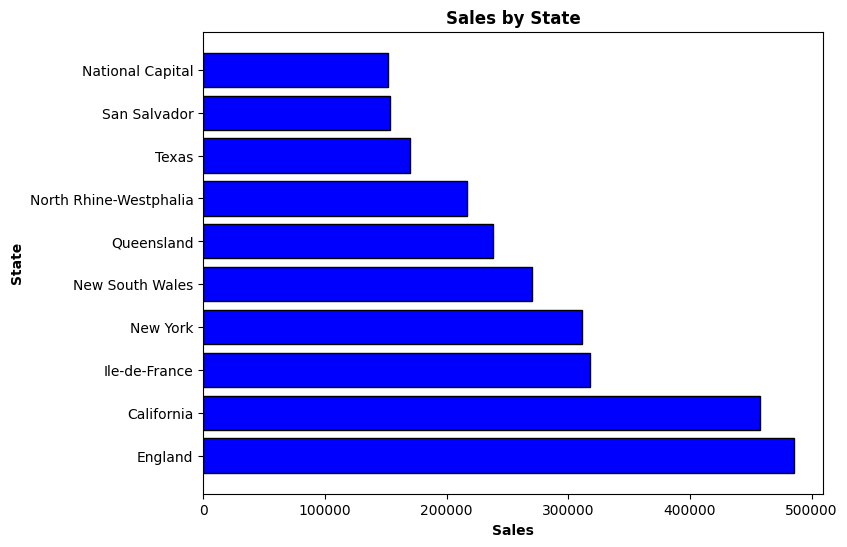

In [25]:
# sales by state

state_sales = (df.groupby('state')['sales'].sum()
.sort_values(ascending = False)
.head(10)
)

plt.figure(figsize=(8,6))

plt.barh(
    state_sales.index,
    state_sales.values,
    color = 'blue',
    edgecolor = 'black'
    )

plt.title('Sales by State',fontweight = 'bold')
plt.ylabel('State',fontweight = 'bold')
plt.xlabel('Sales',fontweight = 'bold')
plt.show()

# Insight:
 England has the highest sales among all states.

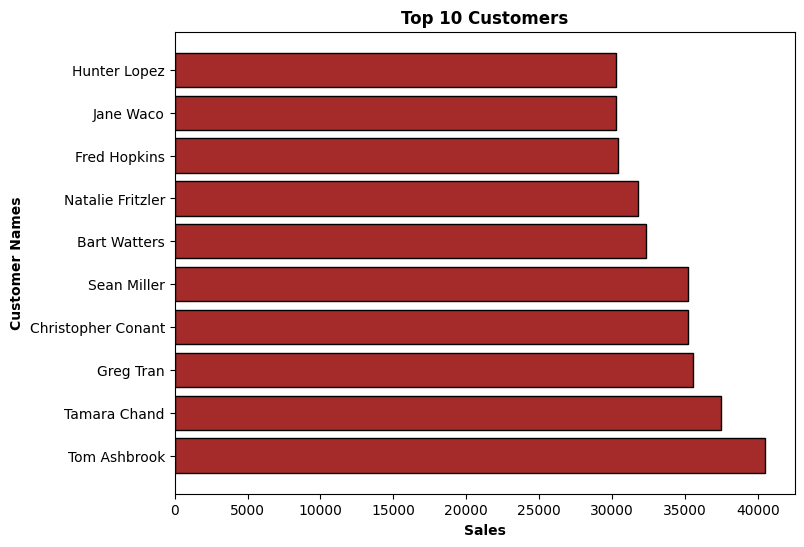

In [26]:
# top 10 customers

top_customers = (df.groupby('customer_name')['sales'].sum()
                .sort_values(ascending=False)
                             .head(10)
                             )

plt.figure(figsize=(8,6))

plt.barh(
    top_customers.index,
    top_customers.values,
    color = 'brown',
    edgecolor = 'black'
)

plt.title('Top 10 Customers',fontweight = 'bold')
plt.xlabel('Sales',fontweight = 'bold')
plt.ylabel('Customer Names',fontweight = 'bold')
plt.show()

# Insight:
Tom Ashbrook generated the highest sales among all customers.

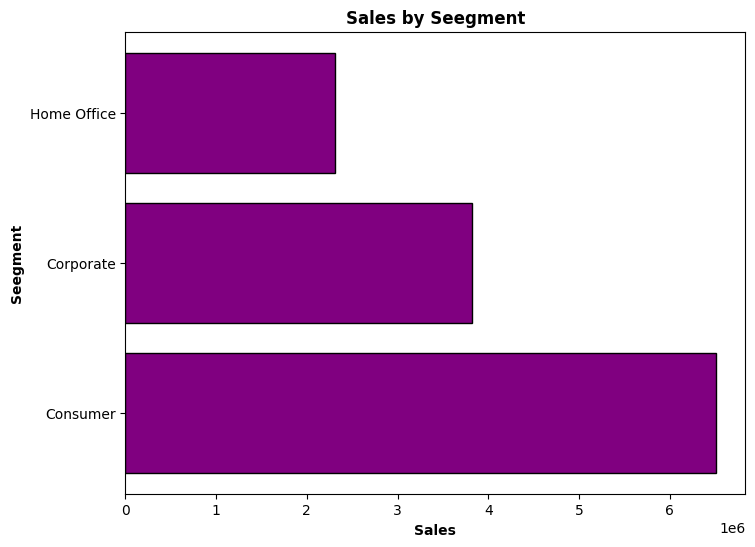

In [27]:
# sales by segment

segment_sales = df.groupby('segment')['sales'].sum()

plt.figure(figsize=(8,6))


plt.barh(
     segment_sales.index,
     segment_sales.values,
    color ='purple',
    edgecolor = 'black'
)

plt.title('Sales by Seegment',fontweight = 'bold')
plt.ylabel('Seegment',fontweight = 'bold')
plt.xlabel('Sales',fontweight = 'bold')
plt.show()


# Insight:
 Consumer segment generates the highest sales.

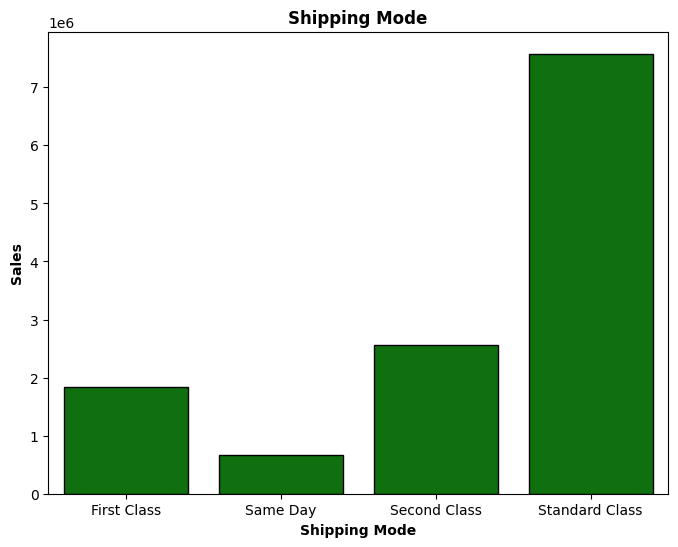

In [28]:
# shipping mode

ship_mode = df.groupby('ship_mode')['sales'].sum()

plt.figure(figsize=(8,6))

sns.barplot(
    x = ship_mode.index,
    y = ship_mode.values,
    color = 'green',
    edgecolor = 'black'
)

plt.title('Shipping Mode',fontweight = 'bold')
plt.xlabel('Shipping Mode',fontweight = 'bold')
plt.ylabel('Sales',fontweight = 'bold')
plt.show()

# Insight:
Standard Class is the most frequently used shipping mode.

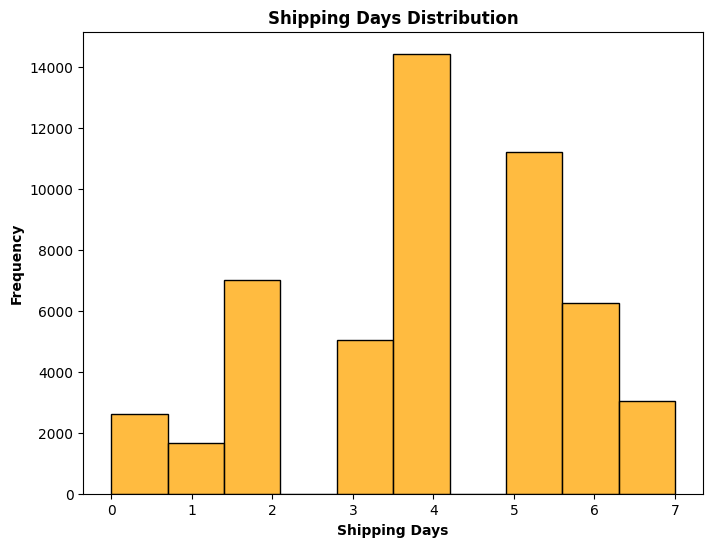

In [29]:
# shipping days distribution
plt.figure(figsize=(8,6))

sns.histplot(
    df['Shipping Days'],
    bins = 10,
    color = 'orange',
    edgecolor = 'black'
)

plt.title('Shipping Days Distribution',fontweight = 'bold')
plt.xlabel('Shipping Days',fontweight = 'bold')
plt.ylabel('Frequency',fontweight = 'bold')
plt.show()

# Insight:
Most orders are delivered within a few days.

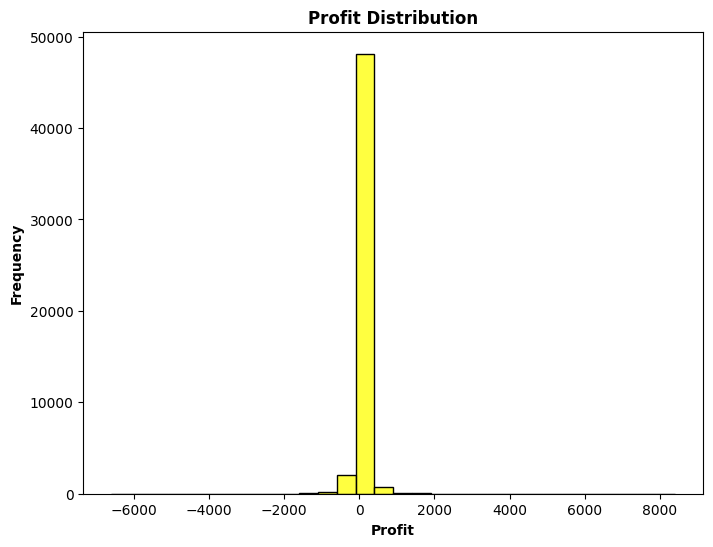

In [30]:
# profit distribution
plt.figure(figsize=(8,6))

sns.histplot(
  df['profit'],
  bins = 30,
  color = 'yellow',
  edgecolor = 'black'
)

plt.title('Profit Distribution',fontweight = 'bold')
plt.xlabel('Profit',fontweight = 'bold')
plt.ylabel('Frequency',fontweight = 'bold')
plt.show()

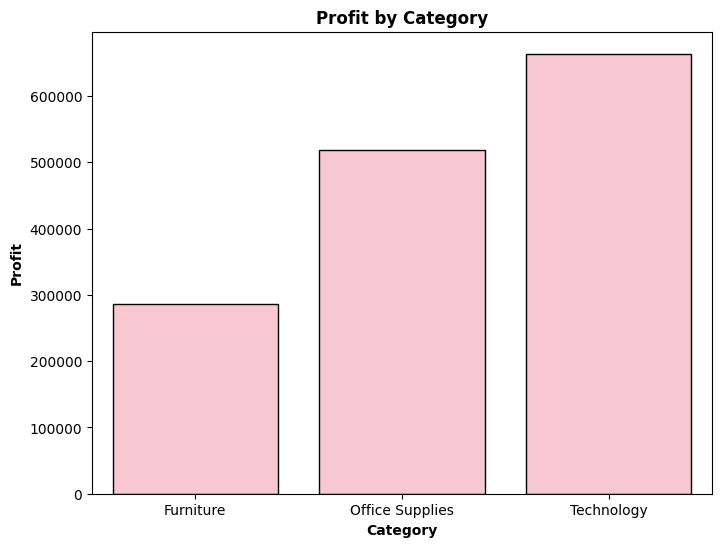

In [31]:
# profit by category
profit_category = df.groupby('category')['profit'].sum()

plt.figure(figsize=(8,6))

sns.barplot(
    x = profit_category.index,
    y = profit_category.values,
    color = 'pink',
    edgecolor = 'black'
)

plt.title('Profit by Category',fontweight = 'bold')
plt.xlabel('Category',fontweight = 'bold')
plt.ylabel('Profit',fontweight = 'bold')
plt.show()

# Insight:
 Technology category generates the highest profit.

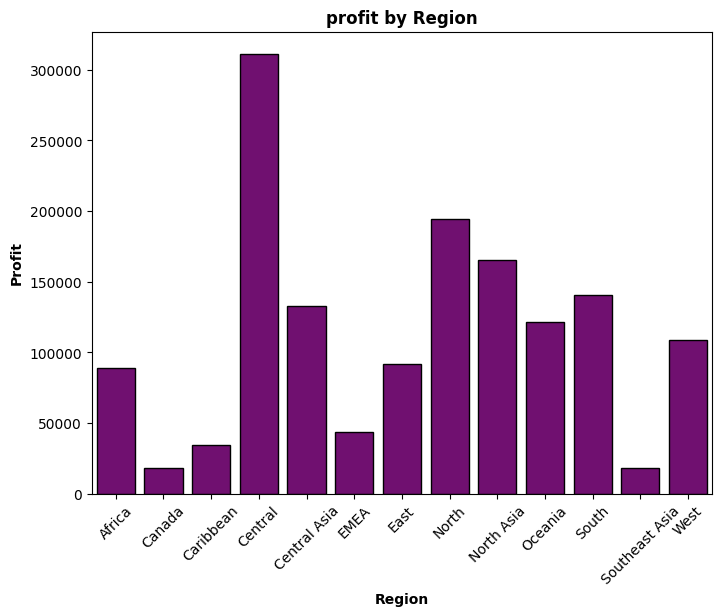

In [32]:
# profit by region

profit_region = df.groupby('region')['profit'].sum()

plt.figure(figsize=(8,6))

sns.barplot(
    x= profit_region.index,
    y= profit_region.values,
    color='purple',
    edgecolor = 'black'
)

plt.title('profit by Region',fontweight = 'bold')
plt.xlabel('Region',fontweight = 'bold')
plt.ylabel('Profit',fontweight = 'bold')
plt.xticks(rotation=45)
plt.show()

# Insight:
 Central region generates the highest profit.

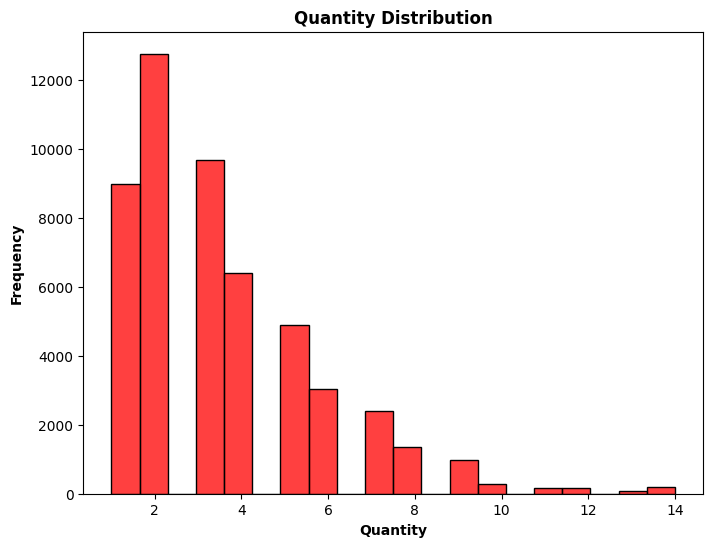

In [33]:
plt.figure(figsize=(8,6))

sns.histplot(
    df['quantity'],
    bins = 20,
    color = 'red',
    edgecolor = 'black'
)

plt.title('Quantity Distribution',fontweight = 'bold')
plt.xlabel('Quantity',fontweight = 'bold')
plt.ylabel('Frequency',fontweight = 'bold')
plt.show()

# Insight:
Most customers purchase small quantities, while large orders are less common.

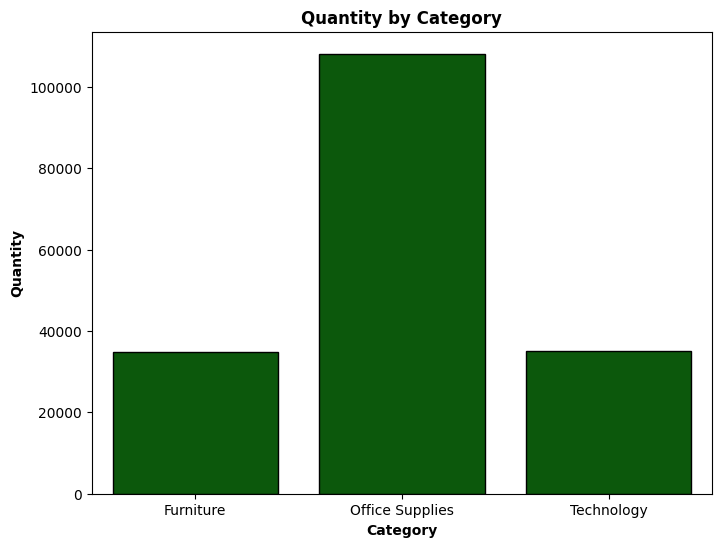

In [34]:
# quantity by category

quantity_category = df.groupby('category')['quantity'].sum()

plt.figure(figsize=(8,6))

sns.barplot(
    x = quantity_category.index,
    y = quantity_category.values,
    color = 'darkgreen',
    edgecolor = 'black'
)

plt.title('Quantity by Category',fontweight = 'bold')
plt.xlabel('Category',fontweight = 'bold')
plt.ylabel('Quantity',fontweight = 'bold')
plt.show()

# Insight:
 Office Supplies category has the highest quantity sold.

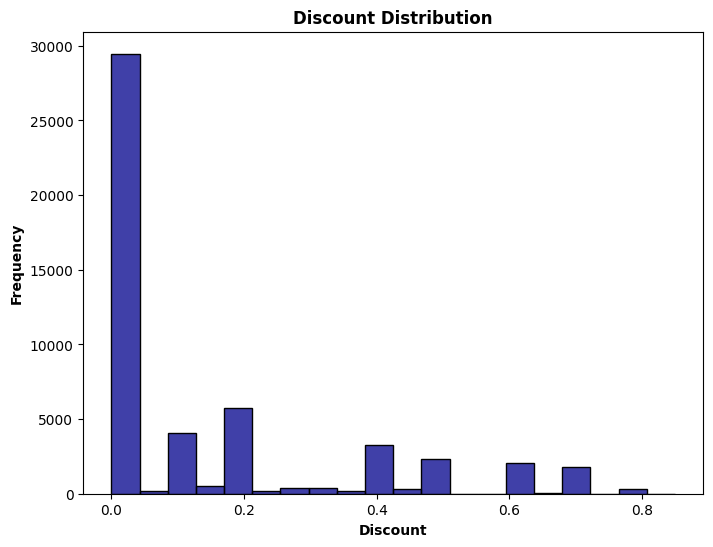

In [35]:
# discount distribution

plt.figure(figsize=(8,6))

sns.histplot(
    df['discount'],
    bins = 20,
    color = 'darkblue',
    edgecolor = 'black'
)

plt.title('Discount Distribution',fontweight = 'bold')
plt.xlabel('Discount',fontweight = 'bold')
plt.ylabel('Frequency',fontweight = 'bold')
plt.show()

# Insight:
 Most orders have little or no discount.

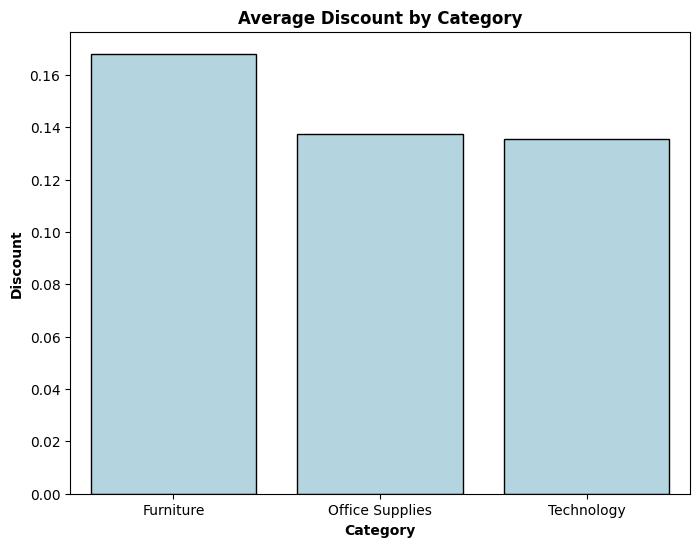

In [36]:
# average discount by category

discount_category = df.groupby('category')['discount'].mean()

plt.figure(figsize=(8,6))

sns.barplot(
    x = discount_category.index,
    y = discount_category.values,
    color = 'lightblue',
    edgecolor = 'black'

)

plt.title('Average Discount by Category',fontweight = 'bold')
plt.xlabel('Category',fontweight = 'bold')
plt.ylabel('Discount',fontweight = 'bold')
plt.show()

# Insight:
 Furniture category receives the highest average discount.

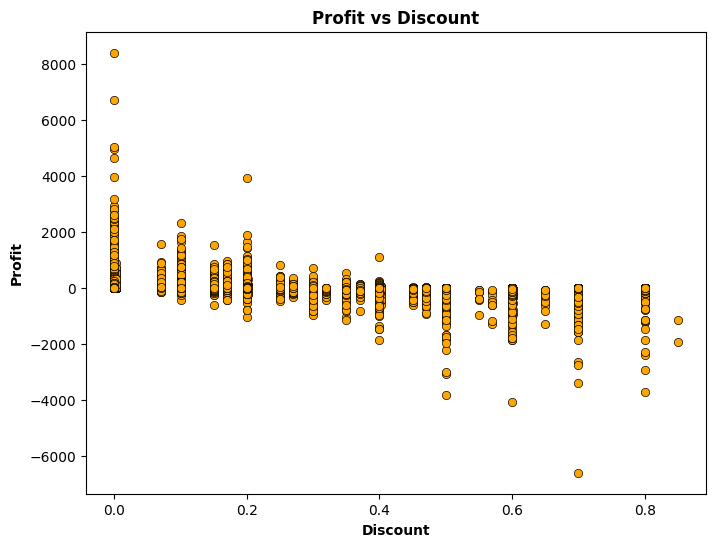

In [37]:
# profit vs discount

plt.figure(figsize=(8,6))

sns.scatterplot(
    x= df['discount'],
    y= df['profit'],
    color = 'orange',
    edgecolor = 'black'
)

plt.title('Profit vs Discount',fontweight = 'bold')
plt.xlabel('Discount',fontweight = 'bold')
plt.ylabel('Profit',fontweight = 'bold')
plt.show()


# Insight:
Profit varies across different discount levels.

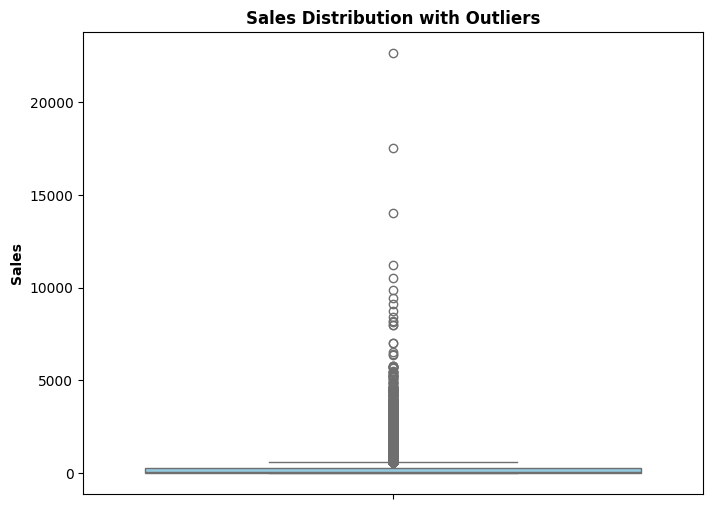

In [38]:
# sales boxplot
plt.figure(figsize=(8,6))

sns.boxplot(
    y = df['sales'],
    color = 'skyblue',

)

plt.title('Sales Distribution with Outliers',fontweight = 'bold')
plt.ylabel('Sales',fontweight = 'bold')
plt.show()

# Insight:
 Most orders have moderate sales, while a few orders have very high sales.

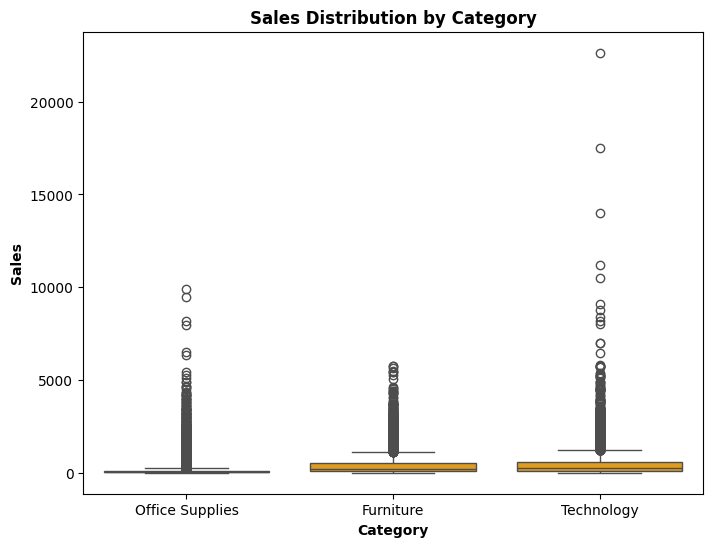

In [39]:
# sales distribution by category
plt.figure(figsize=(8,6))

sns.boxplot(
    data = df,
    x = 'category',
    y = 'sales',
    color = 'orange',
)

plt.title('Sales Distribution by Category',fontweight = 'bold')
plt.xlabel('Category',fontweight = 'bold')
plt.ylabel('Sales',fontweight = 'bold')
plt.show()

# Insight:
Sales vary across categories, with a few high-value sales outliers in each category.

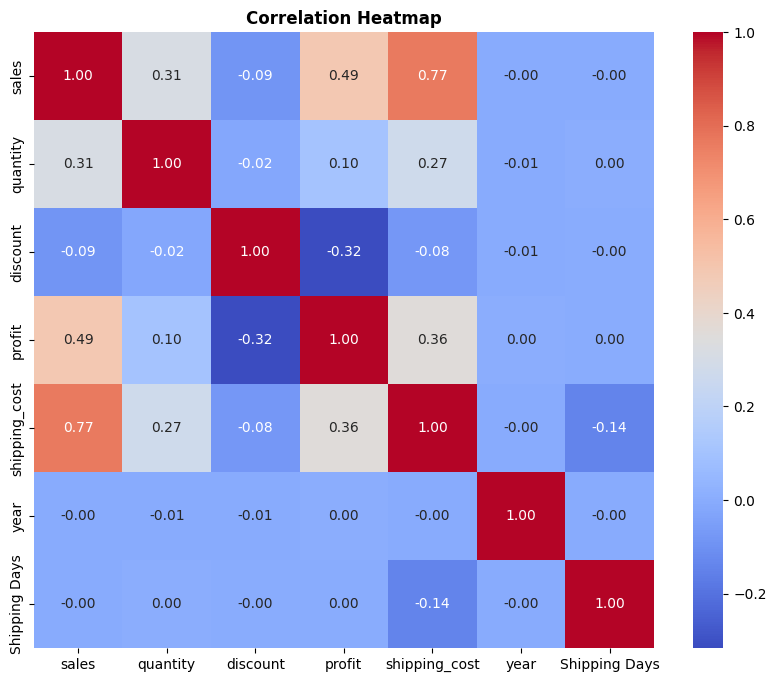

In [40]:
# correlation heatmap
numerical_columns = df.select_dtypes(include=['int64','float64'])

correlation = numerical_columns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f'
)
plt.title('Correlation Heatmap', fontweight='bold')

plt.show()


# Insight:
 Discount has a negative correlation with profit, while sales and profit show a positive correlation.

#**Data Preprocessing**

In this step, I prepared the data for machine learning by encoding categorical columns and selecting the required features.

In [41]:
# degine x and y

features = [
    'ship_mode',
    'segment',
    'state',
    'region',
    'category',
    'sub_category',
    'year',
    'Order Month',
    'Order Day',
    'Day Name',
    'Quarter',
    'Weekend',
    'Shipping Days',
    'discount',
    'order_priority',
    'shipping_cost',
    'market'


]

x = df[features]
y = df['sales']

In [42]:
# Convert categorical columns into numerical format using one-hot encoding.
x = pd.get_dummies(
    x,
    columns=[
        'ship_mode',
        'segment',
        'state',
        'region',
        'category',
        'sub_category',
        'Day Name',
        'year',
        'order_priority',
        'market'
    ],
    drop_first=True
)

#**Model Building and Model Evaluation**

In this step, I trained machine learning models to predict sales using the prepared dataset and then evaluated the model using different performance metrics to check how well it predicts sales.

In [43]:
# train test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    random_state=42
)

In [44]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(41032, 1153)
(10258, 1153)
(41032,)
(10258,)


In [45]:
# model selection and evaluation
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()

lr.fit(x_train,y_train)

lr_pred = lr.predict(x_test)

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("R² Score :", r2_score(y_test, lr_pred))



MAE : 120.7415439969374
MSE : 89503.00755717895
R² Score : 0.6341443249086567


In [46]:
# display actual vs predicted values of Linear Regressor model
comparison = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': lr_pred
})

comparison.head(10)

,Actual Sales,Predicted Sales
0,86,280.828858
1,18,26.280685
2,20,-73.238049
3,60,173.846876
4,1791,385.322646
5,171,335.208504
6,10,136.514354
7,1220,877.831105
8,7,114.366912
9,57,-15.727994


In [47]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(x_train, y_train)

knn_pred = knn.predict(x_test)

print("MAE :", mean_absolute_error(y_test, knn_pred))
print("MSE :", mean_squared_error(y_test, knn_pred))
print("R² Score :", r2_score(y_test, knn_pred))

MAE : 100.64299083642035
MSE : 96268.65421329695
R² Score : 0.6064888271509726


In [48]:
# display actual vs predicted values of K Neighbors Regressor model
comparison_knn = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': knn_pred
})

comparison_knn.head(10)

,Actual Sales,Predicted Sales
0,86,139.8
1,18,42.2
2,20,40.8
3,60,19.0
4,1791,367.2
5,171,149.6
6,10,9.6
7,1220,1098.6
8,7,18.2
9,57,47.0


In [49]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()

dt.fit(x_train, y_train)

dt_pred = dt.predict(x_test)

print("MAE :", mean_absolute_error(y_test, dt_pred))
print("MSE :",mean_squared_error(y_test, dt_pred))
print("R² Score :", r2_score(y_test, dt_pred))

MAE : 96.42639890816923
MSE : 92268.38623513356
R² Score : 0.6228404647287633


In [50]:
# display actual vs predicted values of Decision Tree Regressor model
comparison_dt = pd.DataFrame({
    'Actual Sales':y_test.values,
    'Predicted Sales': dt_pred
})

comparison_dt.head(10)

,Actual Sales,Predicted Sales
0,86,111.0
1,18,9.0
2,20,25.0
3,60,50.0
4,1791,209.0
5,171,144.0
6,10,9.0
7,1220,1472.0
8,7,5.0
9,57,32.0


In [51]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=50,random_state = 42)

rf.fit(x_train,y_train)

rf_pred = rf.predict(x_test)

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("R² Score :", r2_score(y_test, rf_pred))





MAE : 75.90706914928187
MSE : 68305.35909363006
R² Score : 0.7207925862425141


In [53]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    x_train,
    y_train,
    cv=3,
    scoring='r2'
)

print("Cross Validation Scores:", cv_scores)
print("Average R² Score:", cv_scores.mean())

Cross Validation Scores: [0.68872857 0.74138192 0.79353597]
Average R² Score: 0.7412154865913302


# **Cross Validation**

To evaluate the model's stability, 3-fold cross-validation was performed on the Random Forest model.

The average R² score of **0.7412** indicates that the model performs consistently across different subsets of the data, demonstrating good generalization ability.

In [54]:
# display actual vs predicted values of random forest model
comparison_rf = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': rf_pred
})

comparison_rf.head(10)

,Actual Sales,Predicted Sales
0,86,124.66
1,18,15.72
2,20,37.62
3,60,157.12
4,1791,230.74
5,171,231.88
6,10,14.10
7,1220,1031.96
8,7,6.42
9,57,27.44


In [55]:
# display model results
model_results = pd.DataFrame({
    'Model': ['Linear Regression', 'KNN', 'Decision Tree', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, knn_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, knn_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, knn_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ]
})

model_results





,Model,MAE,RMSE,R2 Score
0,Linear Regression,120.741544,299.170533,0.634144
1,KNN,100.642991,310.271904,0.606489
2,Decision Tree,96.426399,303.757117,0.622840
3,Random Forest,75.907069,261.352940,0.720793


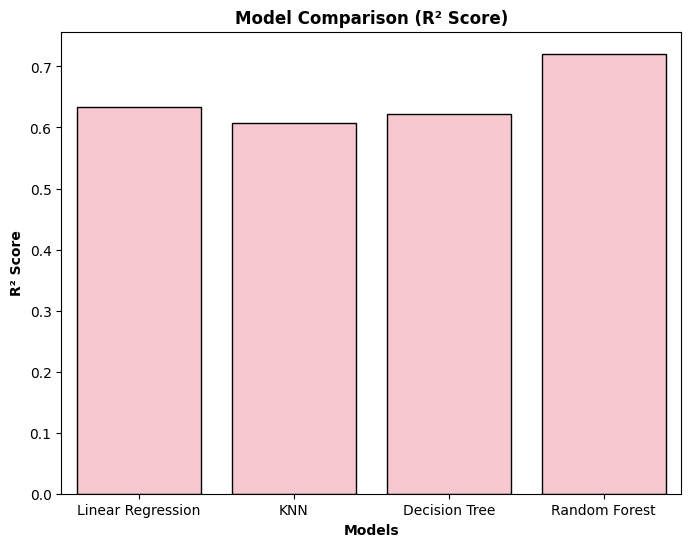

In [56]:
#  model comparison plot
plt.figure(figsize=(8,6))

sns.barplot(
    data=model_results,
    x='Model',
    y='R2 Score',
    color='pink',
    edgecolor = 'black'
)

plt.title('Model Comparison (R² Score)', fontweight='bold')
plt.xlabel('Models', fontweight='bold')
plt.ylabel('R² Score', fontweight='bold')

plt.show()


#**Best Model Selection**

Random Forest achieved the highest R² score among all models. It was selected as the final model because it captures complex relationships in the data and provides more accurate predictions than the other algorithms.

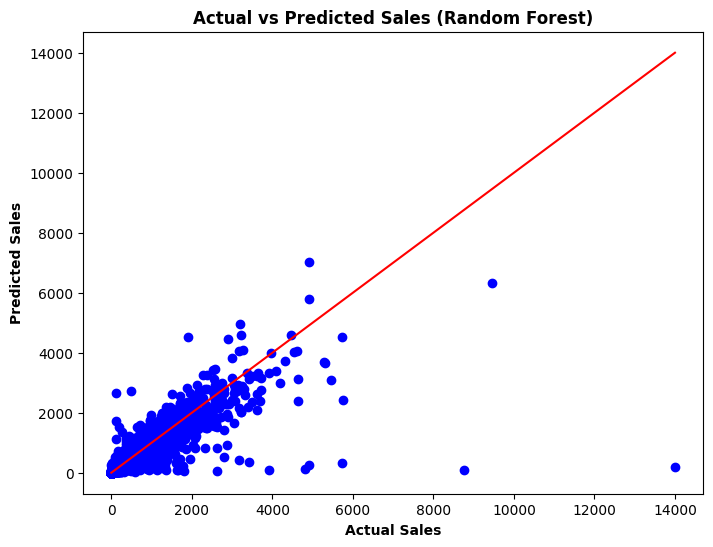

In [57]:
# display Actual vs Predicted sales (random forest) plot
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    rf_pred,
    color='blue',
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(),y_test.max()],
    color='red'

)

plt.title('Actual vs Predicted Sales (Random Forest)', fontweight='bold')
plt.xlabel('Actual Sales', fontweight='bold')
plt.ylabel('Predicted Sales', fontweight='bold')

plt.show()

# **Model Limitations**
- The model is trained on historical sales data.
- External factors such as market trends and customer behavior were not included.
- The model's performance depends on the quality of the input data.

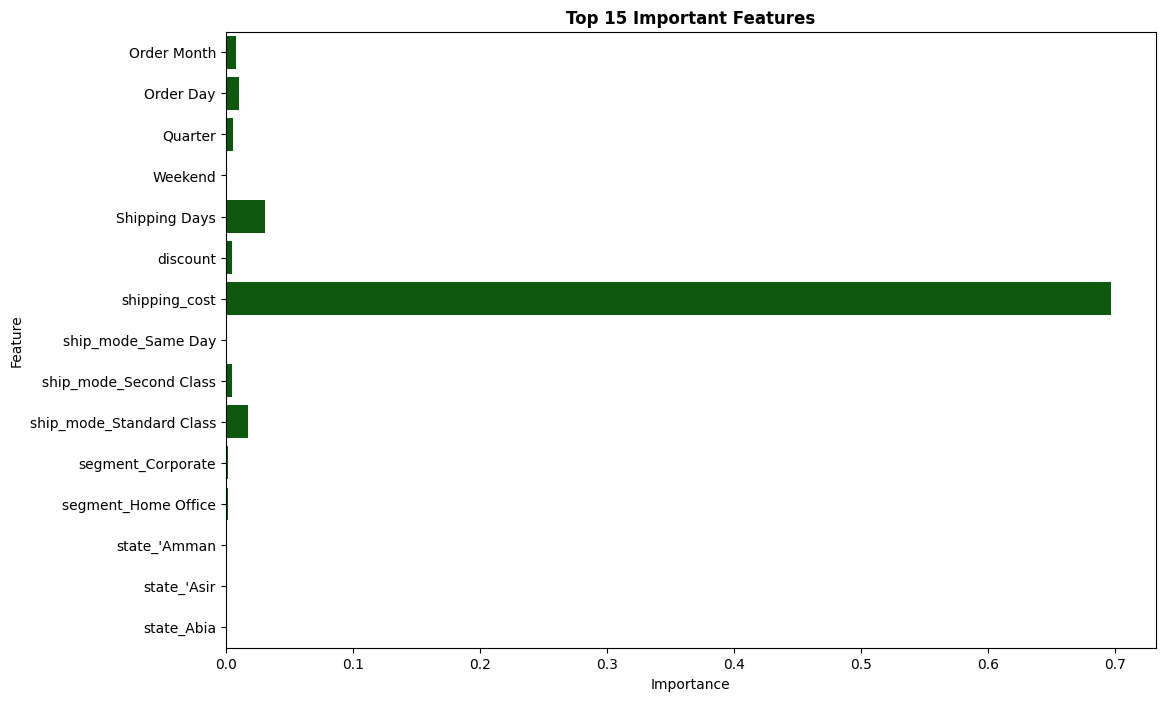

In [58]:
# diaplay top 15 important features
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf.feature_importances_
})



plt.figure(figsize=(12,8))

sns.barplot(
    data = importance.head(15),
    x='Importance',
    y='Feature',
    color='darkgreen'
)

plt.title('Top 15 Important Features', fontweight='bold')

plt.show()

In [59]:

df.to_csv('Cleaned_Sales_data.csv',index=False)

In [60]:
# download cleaned file
from google.colab import files
files.download('Cleaned_Sales_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Business Insights**

Based on the analysis and model results, the following business insights can help improve sales and business decisions.

- The Technology category generated the highest sales among all product categories.
- Standard Class was the most frequently used shipping mode.
- Sales increased during the holiday season, indicating seasonal demand.
- Sales performance varied across regions, with some regions outperforming others.


#**Conclusion**

This project analyzed sales data to identify important business trends and predict future sales using machine learning. Data cleaning, feature engineering, exploratory data analysis, and model building were performed to improve prediction accuracy. An interactive Power BI dashboard was also created to visualize key insights and support data-driven business decisions.

This project demonstrates the complete data science workflow from data preprocessing to visualization and sales prediction.

# **Future Improvement**

- Perform hyperparameter tuning to improve model performance.
- Deploy the model as a web application using Streamlit.
- Retrain the model regularly with new sales data.